In [12]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from John_Jellicoe import algoritmo_JJ
from backtracking import resolver_tablero

from auxiliares import generate_test_case

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [13]:
import time

x = np.linspace(10, 150, 15).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': []
}

for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': []
    }
    
    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(offset_n_m, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))

Tamaño 10x10 ...
Tamaño 20x21 ...
Tamaño 30x31 ...
Tamaño 40x39 ...
Tamaño 50x51 ...
Tamaño 60x61 ...
Tamaño 70x69 ...
Tamaño 80x79 ...
Tamaño 90x89 ...
Tamaño 100x101 ...
Tamaño 110x109 ...
Tamaño 120x120 ...
Tamaño 130x130 ...
Tamaño 140x140 ...
Tamaño 150x150 ...


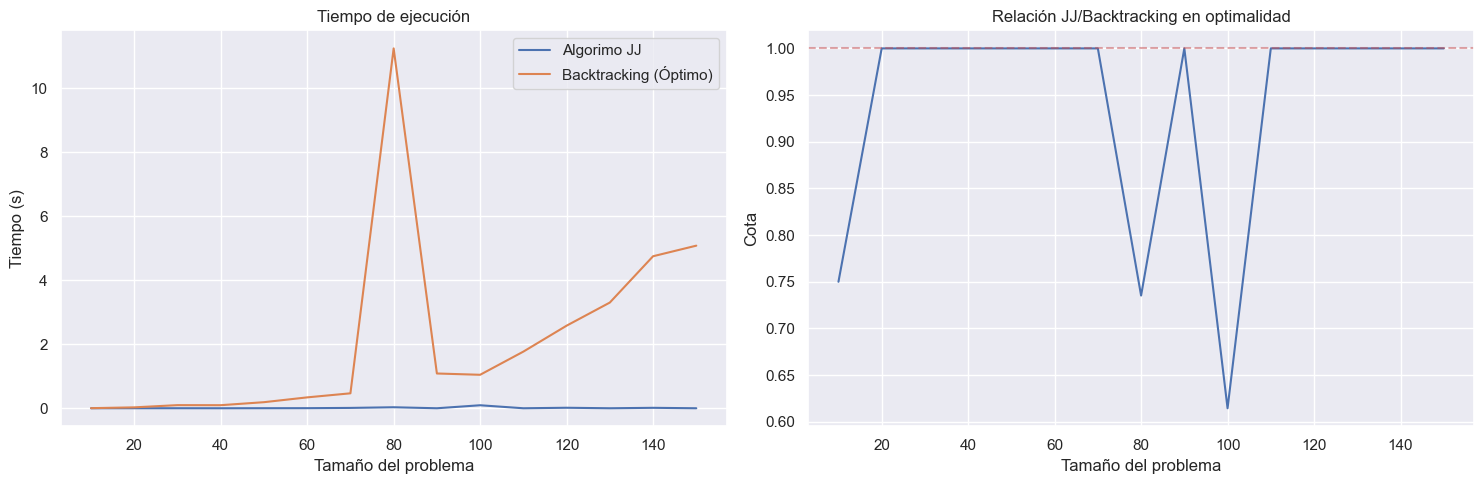

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['size'], results['jj_time'], label='Algorimo JJ')
ax1.plot(results['size'], results['backtrack_time'], label='Backtracking (Óptimo)')
ax1.set_title('Tiempo de ejecución')
ax1.set_xlabel('Tamaño del problema')
ax1.set_ylabel('Tiempo (s)')
ax1.legend()
# ax1.set_yscale('log')

# Plot optimality ratio
ax2.plot(results['size'], results['optimality_ratio'])
ax2.set_title('Relación JJ/Backtracking en optimalidad')
ax2.set_xlabel('Tamaño del problema')
ax2.set_ylabel('Cota')
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
